In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

In [61]:
data_path = "HousePricePrediction Dataset.csv"

df = pd.read_csv(data_path)

In [62]:
print("First 5 Rows:")
print(df.head())

First 5 Rows:
   Id  MSSubClass MSZoning  LotArea LotConfig BldgType  OverallCond  \
0   0          60       RL     8450    Inside     1Fam            5   
1   1          20       RL     9600       FR2     1Fam            8   
2   2          60       RL    11250    Inside     1Fam            5   
3   3          70       RL     9550    Corner     1Fam            5   
4   4          60       RL    14260       FR2     1Fam            5   

   YearBuilt  YearRemodAdd Exterior1st  BsmtFinSF2  TotalBsmtSF  SalePrice  
0       2003          2003     VinylSd         0.0        856.0   208500.0  
1       1976          1976     MetalSd         0.0       1262.0   181500.0  
2       2001          2002     VinylSd         0.0        920.0   223500.0  
3       1915          1970     Wd Sdng         0.0        756.0   140000.0  
4       2000          2000     VinylSd         0.0       1145.0   250000.0  


In [63]:
print("\nDataset Information:")
print(df.info())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            2919 non-null   int64  
 1   MSSubClass    2919 non-null   int64  
 2   MSZoning      2915 non-null   object 
 3   LotArea       2919 non-null   int64  
 4   LotConfig     2919 non-null   object 
 5   BldgType      2919 non-null   object 
 6   OverallCond   2919 non-null   int64  
 7   YearBuilt     2919 non-null   int64  
 8   YearRemodAdd  2919 non-null   int64  
 9   Exterior1st   2918 non-null   object 
 10  BsmtFinSF2    2918 non-null   float64
 11  TotalBsmtSF   2918 non-null   float64
 12  SalePrice     1460 non-null   float64
dtypes: float64(3), int64(6), object(4)
memory usage: 296.6+ KB
None


In [64]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Id                 0
MSSubClass         0
MSZoning           4
LotArea            0
LotConfig          0
BldgType           0
OverallCond        0
YearBuilt          0
YearRemodAdd       0
Exterior1st        1
BsmtFinSF2         1
TotalBsmtSF        1
SalePrice       1459
dtype: int64


In [66]:
df = df.dropna(subset=["SalePrice"])
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())
categorical_cols = df.select_dtypes(include=["object"]).columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
df = pd.get_dummies(df, drop_first=True)

print("\nColumns after Encoding:")
print(df.columns)


Columns after Encoding:
Index(['Id', 'MSSubClass', 'LotArea', 'OverallCond', 'YearBuilt',
       'YearRemodAdd', 'BsmtFinSF2', 'TotalBsmtSF', 'SalePrice', 'MSZoning_FV',
       'MSZoning_RH', 'MSZoning_RL', 'MSZoning_RM', 'LotConfig_CulDSac',
       'LotConfig_FR2', 'LotConfig_FR3', 'LotConfig_Inside', 'BldgType_2fmCon',
       'BldgType_Duplex', 'BldgType_Twnhs', 'BldgType_TwnhsE',
       'Exterior1st_AsphShn', 'Exterior1st_BrkComm', 'Exterior1st_BrkFace',
       'Exterior1st_CBlock', 'Exterior1st_CemntBd', 'Exterior1st_HdBoard',
       'Exterior1st_ImStucc', 'Exterior1st_MetalSd', 'Exterior1st_Plywood',
       'Exterior1st_Stone', 'Exterior1st_Stucco', 'Exterior1st_VinylSd',
       'Exterior1st_Wd Sdng', 'Exterior1st_WdShing'],
      dtype='object')


In [67]:
print("\nData Types:")
print(df.dtypes)


Data Types:
Id                       int64
MSSubClass               int64
LotArea                  int64
OverallCond              int64
YearBuilt                int64
YearRemodAdd             int64
BsmtFinSF2             float64
TotalBsmtSF            float64
SalePrice              float64
MSZoning_FV               bool
MSZoning_RH               bool
MSZoning_RL               bool
MSZoning_RM               bool
LotConfig_CulDSac         bool
LotConfig_FR2             bool
LotConfig_FR3             bool
LotConfig_Inside          bool
BldgType_2fmCon           bool
BldgType_Duplex           bool
BldgType_Twnhs            bool
BldgType_TwnhsE           bool
Exterior1st_AsphShn       bool
Exterior1st_BrkComm       bool
Exterior1st_BrkFace       bool
Exterior1st_CBlock        bool
Exterior1st_CemntBd       bool
Exterior1st_HdBoard       bool
Exterior1st_ImStucc       bool
Exterior1st_MetalSd       bool
Exterior1st_Plywood       bool
Exterior1st_Stone         bool
Exterior1st_Stucco        

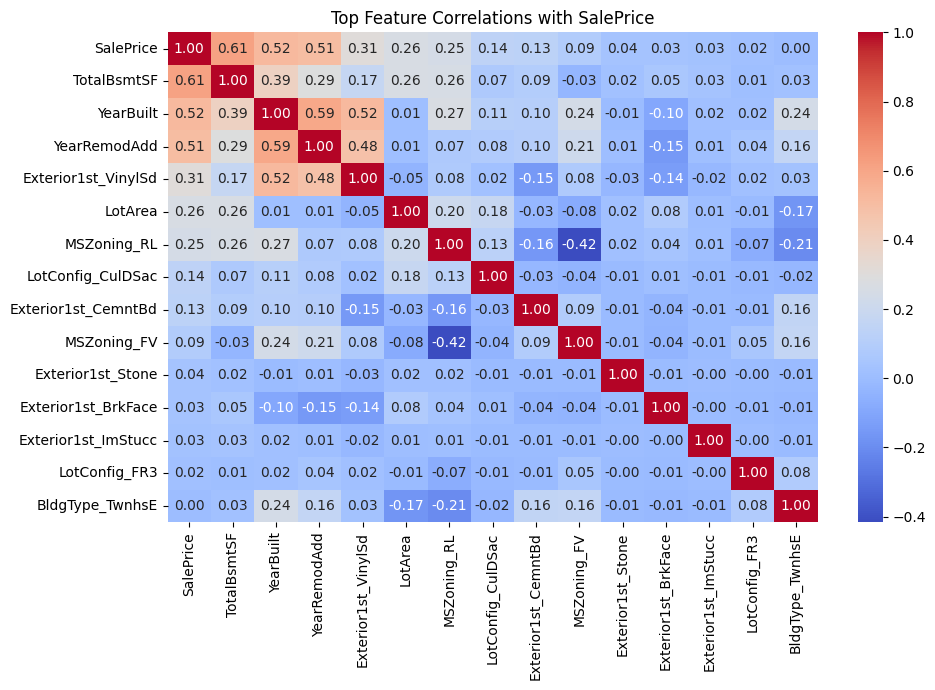

In [69]:
top_corr = df.corr(numeric_only=True)["SalePrice"] \
             .sort_values(ascending=False) \
             .head(15)
top_corr_matrix = df[top_corr.index].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    top_corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Top Feature Correlations with SalePrice")

plt.tight_layout()

plt.savefig("correlation_heatmap.png")

plt.show()

In [70]:
y = df["SalePrice"]
X = df.drop(columns=["SalePrice"])
print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)


Shape of X: (1460, 34)
Shape of y: (1460,)


In [71]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Size:", X_train.shape[0])
print("Testing Size:", X_test.shape[0])


Training Size: 1168
Testing Size: 292


In [72]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("\nModel Training Completed")


Model Training Completed


In [73]:
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\nModel Performance")
print("-------------------")
print("R² Score:", r2)
print("RMSE:", rmse)


Model Performance
-------------------
R² Score: 0.8072248642410472
RMSE: 38453.19461248898


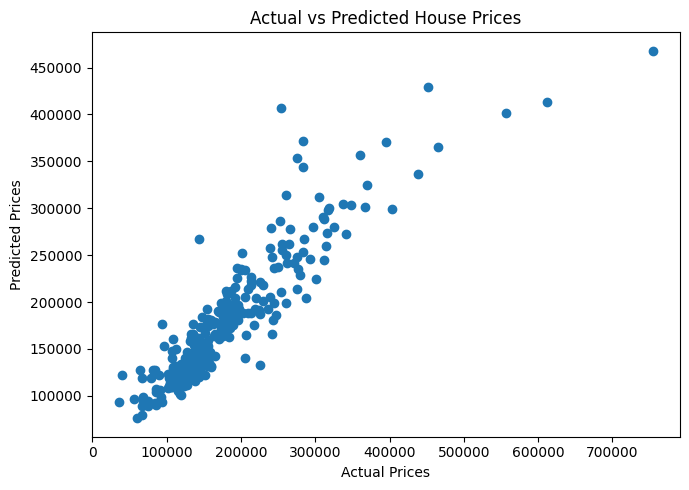

In [75]:
plt.figure(figsize=(7, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Prices")

plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted House Prices")

plt.tight_layout()

plt.savefig("actual_vs_predicted.png")

plt.show()

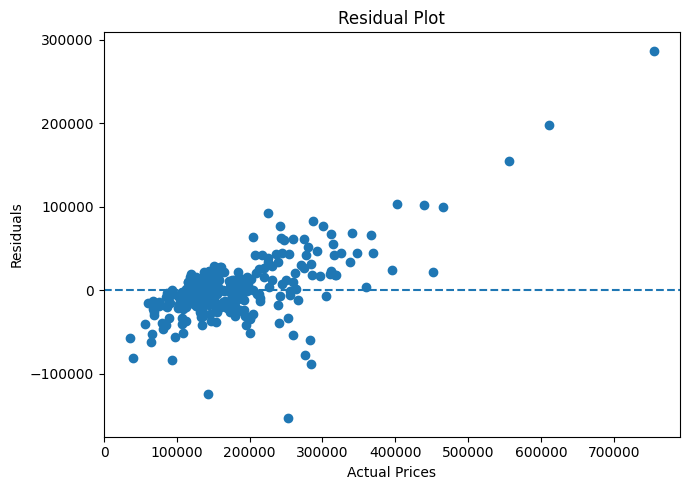

In [76]:
residuals = y_test - y_pred

plt.figure(figsize=(7, 5))

plt.scatter(y_test, residuals)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Actual Prices")

plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.tight_layout()

plt.savefig("residual_plot.png")

plt.show()

In [77]:
new_house = pd.DataFrame([{
    "MSSubClass": 60,
    "LotArea": 8450,
    "OverallCond": 5,
    "YearBuilt": 2003,
    "YearRemodAdd": 2003,
    "BsmtFinSF2": 0,
    "TotalBsmtSF": 856
}])

In [78]:
for col in X.columns:
    if col not in new_house.columns:
        new_house[col] = 0

In [79]:
new_house = new_house[X.columns]
predicted_price = model.predict(new_house)[0]

print("\nPredicted Price for New House:")
print(predicted_price)


Predicted Price for New House:
202715.7
